# 04 - Autoencoder

Trains a PyTorch autoencoder exclusively on benign traffic, then flags anomalies based on reconstruction error on unseen (benign + attack) test data.

**Approach:** unsupervised, trained only on benign rows. Architecture: 78 → 32 → 16 → 8 (encoder) mirrored by an 8 → 16 → 32 → 78 decoder, ReLU activations, MSE loss, Adam optimizer, 20 epochs.

**Key result:** 46% precision / 82% recall on the ANOMALY class — the best-performing model of the three, particularly on recall, which matters most for this forensic use case. Reconstruction error histogram confirms a genuine, visually distinct separation between benign and anomalous flows.

### Load, split, isolate benign-only training set

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('/home/vboxuser/FEAR/data/cicids2017_cleaned.csv')
X = df.drop(columns=['Label', 'Binary_Label'])
y = df['Binary_Label']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_benign = X_train_full[y_train_full == 0]
print(X_train_benign.shape, X_test.shape)

(1466539, 78) (756240, 78)


### Scale features

In [2]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_benign)
X_test_scaled = scaler.transform(X_test)

### Define the Autoencoder architecture

In [3]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = X_train_scaled.shape[1]
model = Autoencoder(input_dim)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=78, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=78, bias=True)
  )
)


### Train the Autoencoder (20 epochs)

In [4]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

import time
start = time.time()
epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for batch, _ in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')
print(f'Training took {time.time()-start:.1f} seconds')

Epoch 1/20, Loss: 0.2957
Epoch 2/20, Loss: 0.1650
Epoch 3/20, Loss: 0.1442
Epoch 4/20, Loss: 0.1349
Epoch 5/20, Loss: 0.1158
Epoch 6/20, Loss: 0.1094
Epoch 7/20, Loss: 0.1016
Epoch 8/20, Loss: 0.0978
Epoch 9/20, Loss: 0.0930
Epoch 10/20, Loss: 0.0909
Epoch 11/20, Loss: 0.0871
Epoch 12/20, Loss: 0.0863
Epoch 13/20, Loss: 0.0835
Epoch 14/20, Loss: 0.0852
Epoch 15/20, Loss: 0.0833
Epoch 16/20, Loss: 0.0831
Epoch 17/20, Loss: 0.0795
Epoch 18/20, Loss: 0.0814
Epoch 19/20, Loss: 0.0774
Epoch 20/20, Loss: 0.0778
Training took 224.6 seconds


### Calculate reconstruction error and visualize

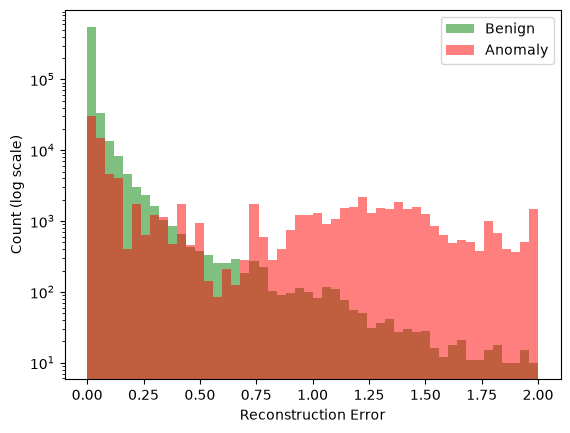

In [14]:
model.eval()
with torch.no_grad():
    reconstructions = model(X_test_tensor)
    reconstruction_errors = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).numpy()

import matplotlib.pyplot as plt
plt.hist(reconstruction_errors[y_test==0], bins=50, range=(0, 2), alpha=0.5, label='Benign', color='green')
plt.hist(reconstruction_errors[y_test==1], bins=50, range=(0, 2), alpha=0.5, label='Anomaly', color='red' )
plt.yscale('log')
plt.legend()
plt.xlabel('Reconstruction Error')
plt.ylabel('Count (log scale)')
plt.savefig('/home/vboxuser/FEAR/results/autoencoder_reconstruction_error.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

threshold = np.percentile(reconstruction_errors[y_test==0], 80)
preds_binary = (reconstruction_errors > threshold).astype(int)

print(confusion_matrix(y_test, preds_binary))
print(classification_report(y_test, preds_binary))

[[502814 125704]
 [ 22412 105310]]
              precision    recall  f1-score   support

           0       0.96      0.80      0.87    628518
           1       0.46      0.82      0.59    127722

    accuracy                           0.80    756240
   macro avg       0.71      0.81      0.73    756240
weighted avg       0.87      0.80      0.82    756240

